In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')) + '/..')

from XSpect import Pipeline
import numpy as np
import matplotlib.pyplot as plt

p = Pipeline.from_yaml('examples/mfx101609126_seer_xrt.yaml')
p.run(cores=4, batch_size=500)

run_results = []
for run in p.analyzed_runs:
    xrt_2d  = getattr(run, 'epix_xrt_reduced',        None)   # (60, 300) summed XRT image
    seer_2d = getattr(run, 'epix_seer_reduced',       None)   # summed SEER image
    xrt_1d  = getattr(run, 'epix_xrt_reduced_ROI_1',  None)   # (300,) XRT 1D spectrum
    seer_1d = getattr(run, 'epix_seer_reduced_ROI_1', None)   # SEER 1D spectrum
    run_results.append({
        'run_number':  run.run_number,
        'total_shots': run.total_shots,
        'xrt_2d':  xrt_2d,
        'seer_2d': seer_2d,
        'xrt_1d':  xrt_1d,
        'seer_1d': seer_1d,
    })
    print(f'Run: {run.run_number}')
    print(f'  Total shots:     {run.total_shots}')
    print(f'  XRT  2D image:   {xrt_2d.shape  if xrt_2d  is not None else "not available"}')
    print(f'  SEER 2D image:   {seer_2d.shape if seer_2d is not None else "not available"}')
    print(f'  XRT  1D spectrum:{xrt_1d.shape  if xrt_1d  is not None else "not available"}')
    print(f'  SEER 1D spectrum:{seer_1d.shape if seer_1d is not None else "not available"}')
    print()

Run: 79
  Total shots:     35998
  XRT  2D image:   (60, 300)
  SEER 2D image:   (100, 620)
  XRT  1D spectrum:(300,)
  SEER 1D spectrum:(620,)



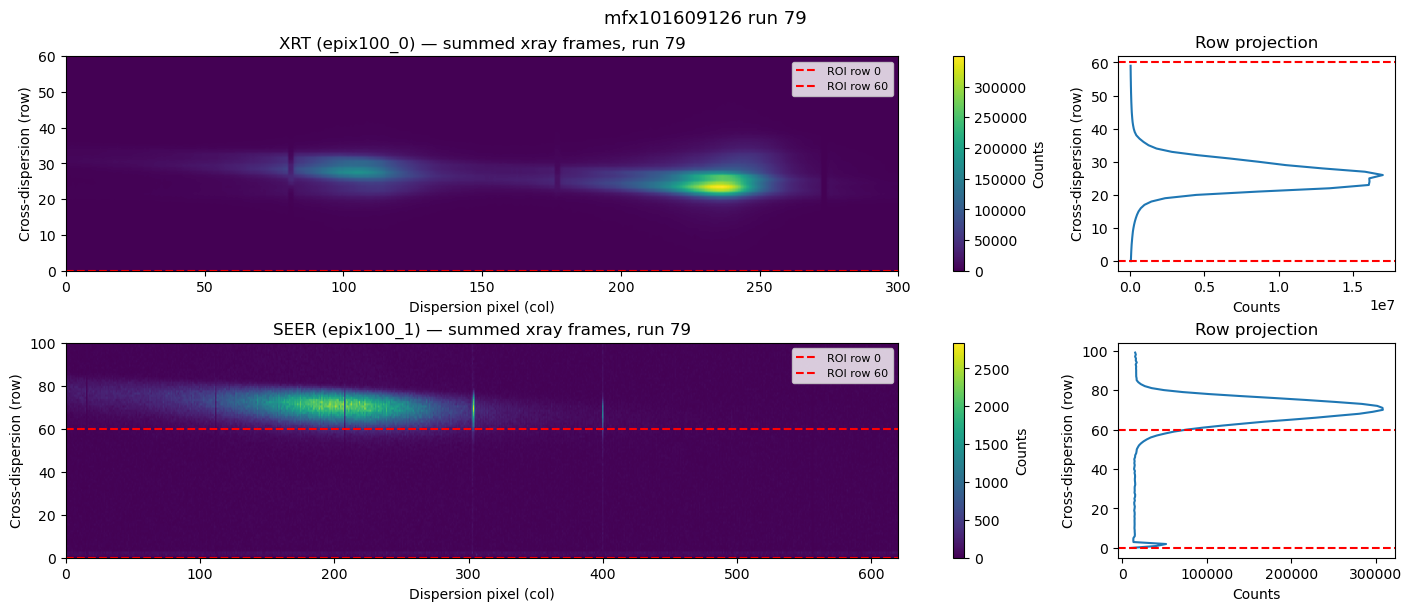

In [2]:
# --- 2D image diagnostics ---
# Summed xray frames for each spectrometer with spatial ROI band marked.
# Adjust rois: [[row_start, row_end]] in the YAML if the red band misses the signal.

roi_rows = [0, 60]   # must match rois: [[0, 60]] in the YAML

for res in run_results:
    run_num = res['run_number']

    fig, axes = plt.subplots(2, 2, figsize=(14, 6),
                             gridspec_kw={'width_ratios': [3, 1]},
                             constrained_layout=True)
    fig.suptitle(f'mfx101609126 run {run_num}', fontsize=13)

    for row_idx, (label, img) in enumerate([('XRT (epix100_0)',  res['xrt_2d']),
                                             ('SEER (epix100_1)', res['seer_2d'])]):
        ax_img  = axes[row_idx, 0]
        ax_proj = axes[row_idx, 1]

        if img is None:
            ax_img.text(0.5, 0.5, f'{label}\nno data', ha='center', va='center',
                       transform=ax_img.transAxes, fontsize=12)
            ax_proj.set_visible(False)
            continue

        im = ax_img.imshow(img, aspect='auto', origin='lower',
                           extent=[0, img.shape[1], 0, img.shape[0]],
                           cmap='viridis')
        plt.colorbar(im, ax=ax_img, label='Counts')
        ax_img.axhline(roi_rows[0], color='red', ls='--', lw=1.5, label=f'ROI row {roi_rows[0]}')
        ax_img.axhline(roi_rows[1], color='red', ls='--', lw=1.5, label=f'ROI row {roi_rows[1]}')
        ax_img.set_xlabel('Dispersion pixel (col)')
        ax_img.set_ylabel('Cross-dispersion (row)')
        ax_img.set_title(f'{label} — summed xray frames, run {run_num}')
        ax_img.legend(fontsize=8)

        row_proj = img.sum(axis=1)   # sum over dispersion axis → signal vs row
        ax_proj.plot(row_proj, np.arange(len(row_proj)))
        ax_proj.axhline(roi_rows[0], color='red', ls='--', lw=1.5)
        ax_proj.axhline(roi_rows[1], color='red', ls='--', lw=1.5)
        ax_proj.set_xlabel('Counts')
        ax_proj.set_ylabel('Cross-dispersion (row)')
        ax_proj.set_title('Row projection')

    plt.show()

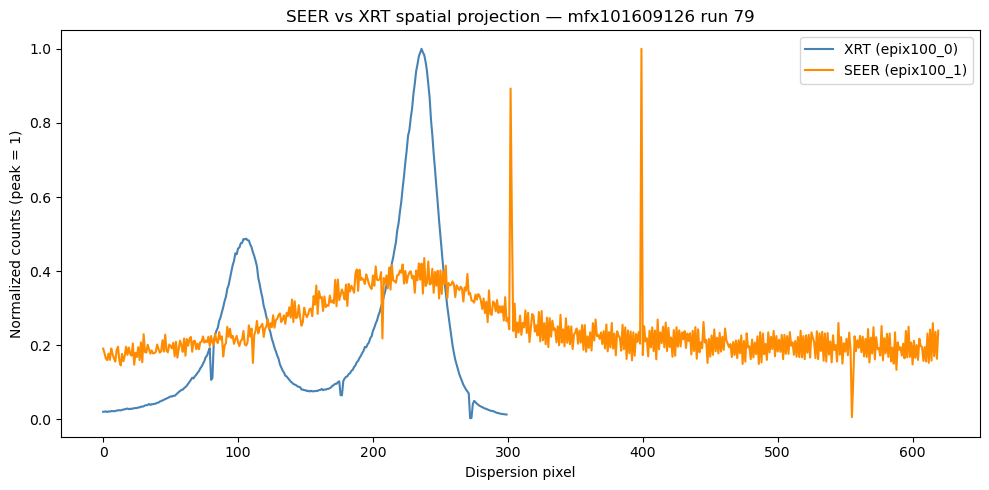

In [3]:
# --- SEER vs XRT overlay ---
# Both spectra spatially integrated (rows summed) and normalized to their peak
# so they can be compared on the same y-axis regardless of absolute count scale.

for res in run_results:
    run_num = res['run_number']
    xrt_1d  = res['xrt_1d']
    seer_1d = res['seer_1d']

    fig, ax = plt.subplots(figsize=(10, 5))

    if xrt_1d is not None:
        xrt_norm = xrt_1d / np.nanmax(xrt_1d)
        ax.plot(np.arange(len(xrt_1d)), xrt_norm, color='steelblue', lw=1.5, label='XRT (epix100_0)')
    else:
        ax.text(0.5, 0.6, 'XRT data not available', ha='center', transform=ax.transAxes)

    if seer_1d is not None:
        seer_norm = seer_1d / np.nanmax(seer_1d)
        ax.plot(np.arange(len(seer_1d)), seer_norm, color='darkorange', lw=1.5, label='SEER (epix100_1)')
    else:
        ax.text(0.5, 0.4, 'SEER data not available\n(epix100_1 not recorded in this run)',
                ha='center', transform=ax.transAxes, color='grey', fontsize=10)

    ax.set_xlabel('Dispersion pixel')
    ax.set_ylabel('Normalized counts (peak = 1)')
    ax.set_title(f'SEER vs XRT spatial projection — mfx101609126 run {run_num}')
    ax.legend()
    plt.tight_layout()
    plt.show()